In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io

csv_data = """ProductID,ProductName,Category,Price,UnitsSold
101,Laptop,Electronics,1200,50
102,Mouse,Electronics,25,200
103,Keyboard,Electronics,75,150
104,T-Shirt,Apparel,20,300
105,Jeans,Apparel,95,120
106,Coffee Mug,Homeware,15,500
"""

df = pd.read_csv(io.StringIO(csv_data)) # Load CSV data from a string using StringIO as a file-like object

print(df["ProductName"])

0        Laptop
1         Mouse
2      Keyboard
3       T-Shirt
4         Jeans
5    Coffee Mug
Name: ProductName, dtype: object


In [7]:
df['Revenue']=df['Price']*df['UnitsSold']
df['Revenue']

0    60000
1     5000
2    11250
3     6000
4    11400
5     7500
Name: Revenue, dtype: int64

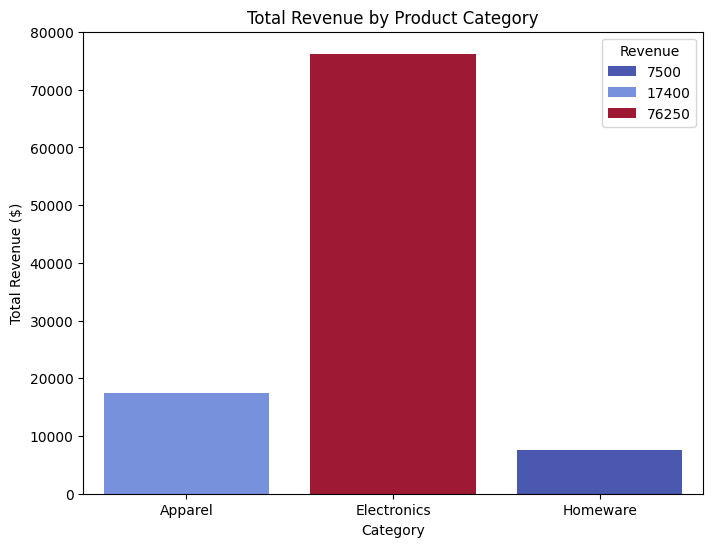

In [11]:
# Now let's plot the total revenue by category
plt.figure(figsize=(8, 6))

category_revenue = df.groupby('Category')['Revenue'].sum().reset_index()

sns.barplot(x='Category', y='Revenue', data=category_revenue, hue='Revenue', palette='coolwarm')

plt.title('Total Revenue by Product Category')
plt.xlabel('Category')

plt.ylabel('Total Revenue ($)')
plt.show()


## color code

'viridis'

'plasma'

'inferno'

'magma'

'cividis'

'coolwarm'

'Spectral'

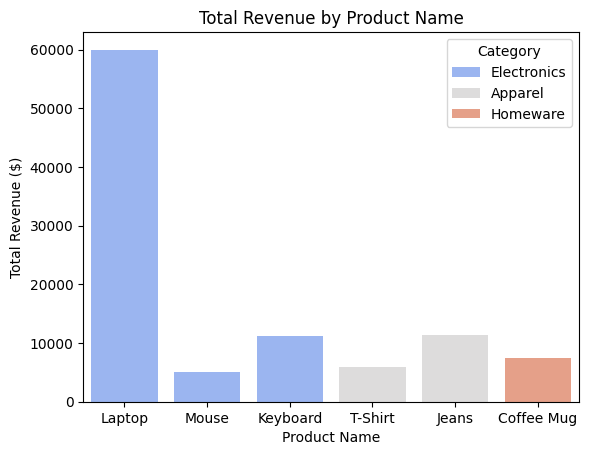

In [12]:
sns.barplot(x='ProductName', y='Revenue', data=df, hue='Category', palette='coolwarm')

plt.title('Total Revenue by Product Name')
plt.xlabel('Product Name')

plt.ylabel('Total Revenue ($)')
plt.show()


Analyze and visualize data 
Goal: Create a dashboard of 2-3 plots that tell a story about teh sales data

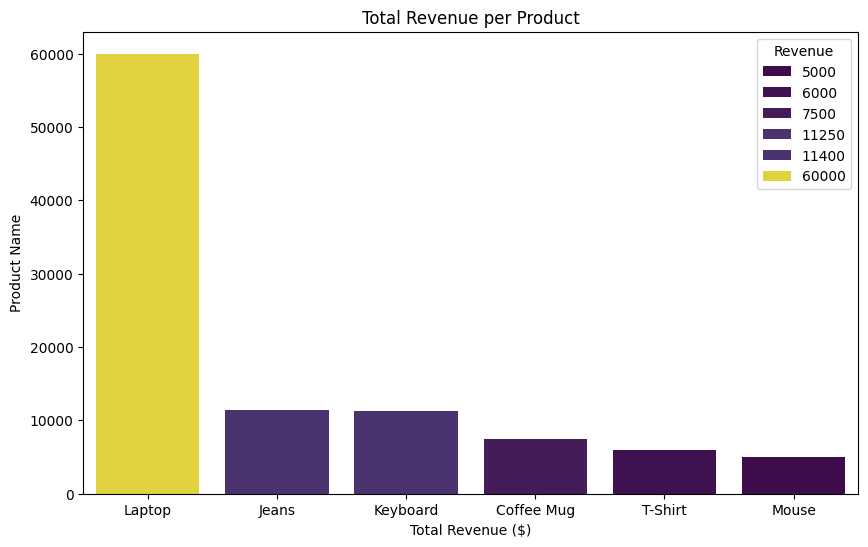

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(y='Revenue',x='ProductName', hue='Revenue', data=df.sort_values('Revenue', ascending=False),palette='viridis')
plt.title('Total Revenue per Product')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Name')
plt.show()

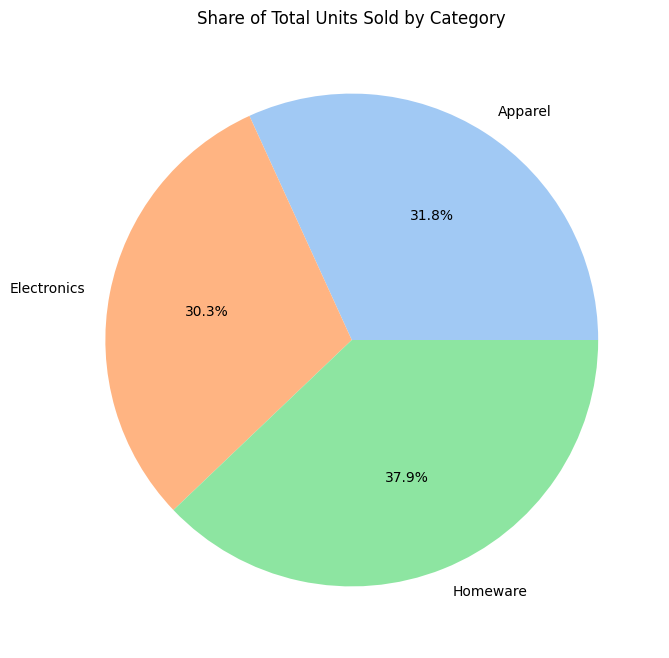

In [16]:
# Plot 2: How do the categories compare in terms of units sold?
category_units = df.groupby('Category')['UnitsSold'].sum().reset_index()
plt.figure(figsize=(8, 8))
plt.pie(category_units['UnitsSold'], labels=category_units['Category'], autopct='%1.1f%%', startangle=0, colors=sns.color_palette('pastel'))
plt.title('Share of Total Units Sold by Category')
plt.ylabel('')
plt.show()

In [ ]:
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales

In [35]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
df=pd.read_csv('SuperMarket Analysis.csv')
# Convert 'Date' column to datetime objects for time-series analysis
df['Date'] = pd.to_datetime(df['Date'])


df.head(10)


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic accessories,85.39,7,29.8865,627.6165,2019-03-25,6:30:00 PM,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic accessories,68.84,6,20.6520,433.6920,2019-02-25,2:36:00 PM,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home and lifestyle,73.56,10,36.7800,772.3800,2019-02-24,11:38:00 AM,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health and beauty,36.26,2,3.6260,76.1460,2019-01-10,5:15:00 PM,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food and beverages,54.84,3,8.2260,172.7460,2019-02-20,1:27:00 PM,Credit card,164.52,4.761905,8.2260,5.9


In [36]:
df.shape

(1000, 17)

In [37]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df=df.sort_values('Date',ascending=True)
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
856,770-42-8960,Cairo,Mandalay,Normal,Male,Food and beverages,21.12,8,8.448,177.408,2019-01-01,7:31:00 PM,Cash,168.96,4.761905,8.448,6.3
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,2019-01-01,1:55:00 PM,Cash,591.66,4.761905,29.583,7.7
245,530-90-9855,Alex,Yangon,Member,Male,Home and lifestyle,47.59,8,19.036,399.756,2019-01-01,2:47:00 PM,Cash,380.72,4.761905,19.036,5.7
696,182-52-7000,Alex,Yangon,Member,Female,Sports and travel,27.04,4,5.408,113.568,2019-01-01,8:26:00 PM,Ewallet,108.16,4.761905,5.408,6.9
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health and beauty,62.87,2,6.287,132.027,2019-01-01,11:43:00 AM,Cash,125.74,4.761905,6.287,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,743-04-1105,Cairo,Mandalay,Member,Male,Health and beauty,97.22,9,43.749,918.729,2019-03-30,2:43:00 PM,Ewallet,874.98,4.761905,43.749,6.0
881,115-38-7388,Giza,Naypyitaw,Member,Female,Fashion accessories,10.18,8,4.072,85.512,2019-03-30,12:51:00 PM,Credit card,81.44,4.761905,4.072,9.5
963,364-34-2972,Giza,Naypyitaw,Member,Male,Electronic accessories,96.82,3,14.523,304.983,2019-03-30,8:37:00 PM,Cash,290.46,4.761905,14.523,6.7
937,361-85-2571,Alex,Yangon,Normal,Female,Sports and travel,89.48,5,22.370,469.770,2019-03-30,10:18:00 AM,Cash,447.40,4.761905,22.370,7.4


In [40]:
df=df.sort_values(by=['Date','Time'],ascending=True)
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
17,765-26-6951,Alex,Yangon,Member,Female,Sports and travel,72.61,6,21.783,457.443,2019-01-01,10:39:00 AM,Credit card,435.66,4.761905,21.783,6.9
970,746-04-1077,Cairo,Mandalay,Member,Female,Food and beverages,84.63,10,42.315,888.615,2019-01-01,11:36:00 AM,Credit card,846.30,4.761905,42.315,9.0
839,271-77-8740,Giza,Naypyitaw,Member,Female,Sports and travel,29.22,6,8.766,184.086,2019-01-01,11:40:00 AM,Ewallet,175.32,4.761905,8.766,5.0
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health and beauty,62.87,2,6.287,132.027,2019-01-01,11:43:00 AM,Cash,125.74,4.761905,6.287,5.0
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion accessories,65.74,9,29.583,621.243,2019-01-01,1:55:00 PM,Cash,591.66,4.761905,29.583,7.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
671,642-61-4706,Cairo,Mandalay,Member,Male,Food and beverages,93.40,2,9.340,196.140,2019-03-30,4:34:00 PM,Cash,186.80,4.761905,9.340,5.5
474,676-39-6028,Alex,Yangon,Member,Female,Electronic accessories,64.44,5,16.110,338.310,2019-03-30,5:04:00 PM,Cash,322.20,4.761905,16.110,6.6
473,731-59-7531,Cairo,Mandalay,Member,Male,Health and beauty,72.57,8,29.028,609.588,2019-03-30,5:58:00 PM,Cash,580.56,4.761905,29.028,4.6
643,131-15-8856,Giza,Naypyitaw,Member,Female,Food and beverages,72.52,8,29.008,609.168,2019-03-30,7:26:00 PM,Credit card,580.16,4.761905,29.008,4.0


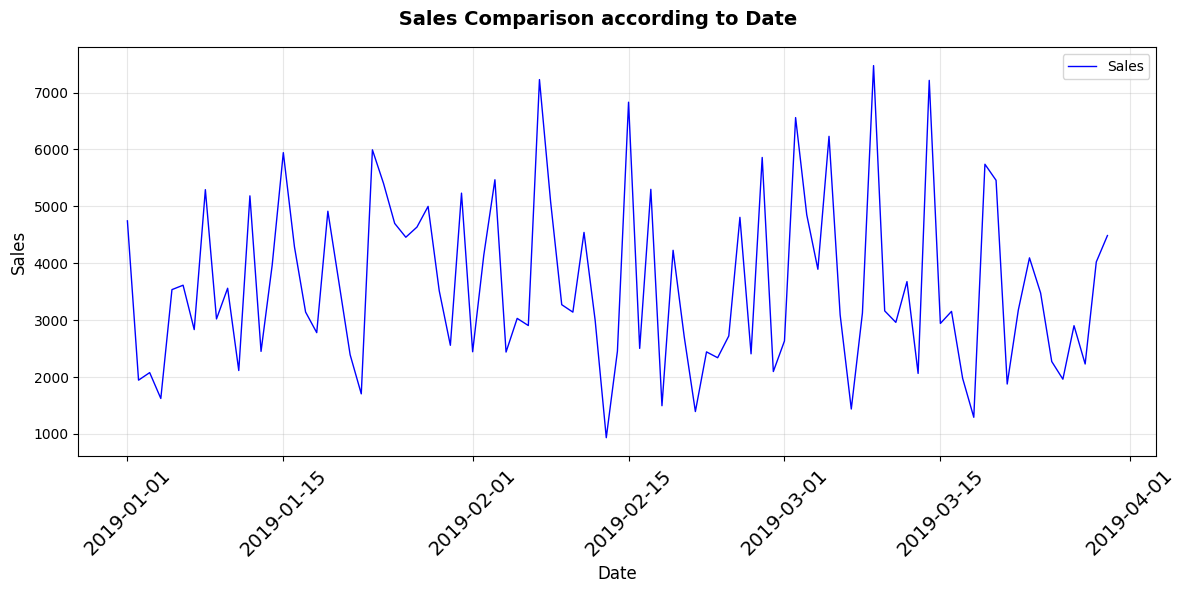

In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
daily_Sales = df.groupby('Date')['Sales'].sum().reset_index()
plt.figure(figsize=(12,6))
plt.plot(daily_Sales['Date'],daily_Sales['Sales'], linewidth=1, label='Sales', color='blue')
plt.suptitle(' Sales Comparison according to Date', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.xticks(rotation=45,fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

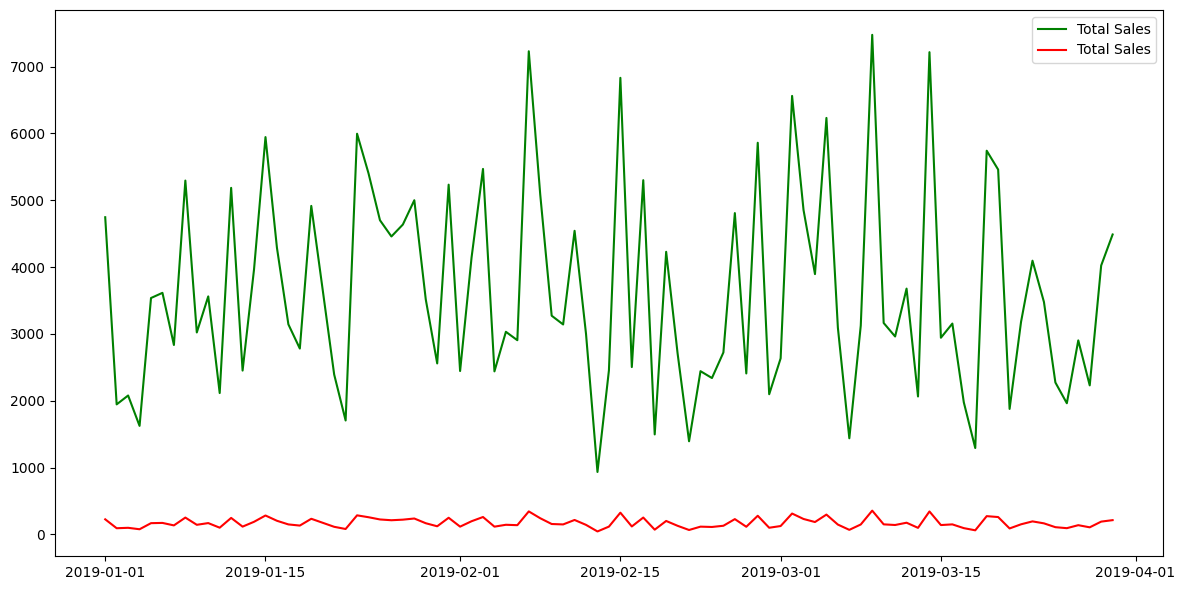

In [61]:
# First, let's aggregate daily sales
daily_income = df.groupby('Date')[['gross income', 'Sales']].sum().reset_index()


# Create a Matplotlib plot
plt.figure(figsize=(12, 6))




plt.plot(daily_income['Date'], daily_income['Sales'], label='Total Sales', color='green')
plt.plot(daily_income['Date'], daily_income['gross income'], label='Total Sales', color='red')
plt.legend()
plt.tight_layout()
plt.show()

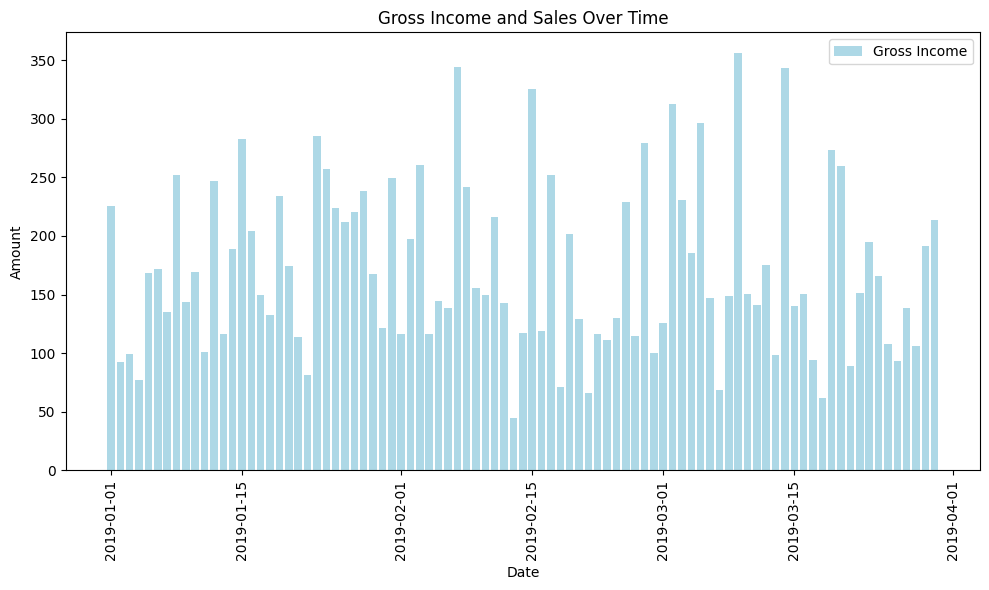

In [62]:
plt.figure(figsize=(10, 6))

plt.bar(daily_income['Date'], daily_income['gross income'], label='Gross Income', color='lightblue')


plt.title('Gross Income and Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [63]:
daily_income[daily_income['Date'] == '2019-02-13']

,Date,gross income,Sales
43,2019-02-13,44.4875,934.2375


In [64]:
df['Branch'].unique()

array(['Alex', 'Cairo', 'Giza'], dtype=object)

In [66]:
daily_income_branch=df.groupby('Branch')[['Sales']].sum().reset_index()
daily_income_branch

,Branch,Sales
0,Alex,106200.3705
1,Cairo,106197.6720
2,Giza,110568.7065


In [68]:
daily_income_product_line = df.groupby('Product line')[['Sales']].sum().reset_index()
daily_income_product_line

,Product line,Sales
0,Electronic accessories,54337.5315
1,Fashion accessories,54305.8950
2,Food and beverages,56144.8440
3,Health and beauty,49193.7390
4,Home and lifestyle,53861.9130
5,Sports and travel,55122.8265


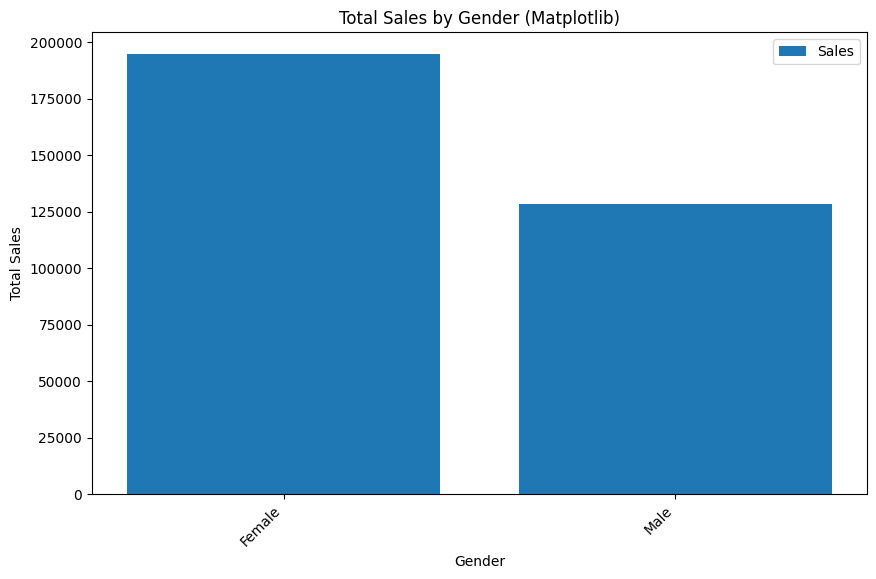

In [71]:
# Aggregate sales by product line
product_sales = df.groupby('Gender')['Sales'].sum().sort_values(ascending=False)
# Create a Matplotlib bar chart
plt.figure(figsize=(10, 6))

plt.bar(product_sales.index, product_sales.values, label='Sales')

plt.title('Total Sales by Gender (Matplotlib)')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.show()

In [72]:
product_sales

Gender
Female    194671.8375
Male      128294.9115
Name: Sales, dtype: float64

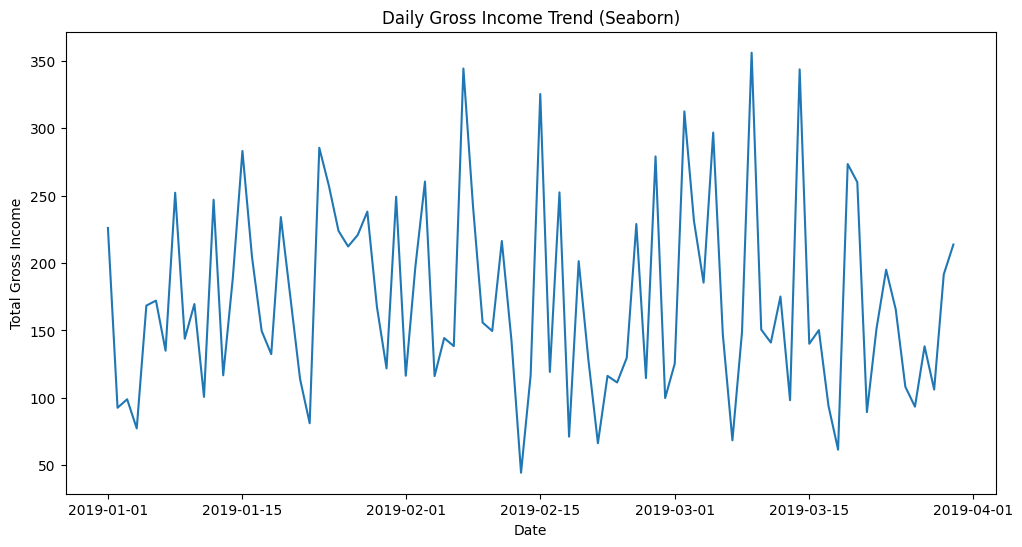

In [73]:
# Create the same line plot with Seaborn
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='Date', y='gross income', estimator=sum, errorbar=None) # estimator=sum aggregates the data for us

plt.title('Daily Gross Income Trend (Seaborn)')
plt.xlabel('Date')
plt.ylabel('Total Gross Income')

plt.show()



In [74]:
# Bar chart showing counts of each customer type
plt.figure(figsize=(140,15))
sns.countplot(data=df, x='Date', hue='Gender', palette='viridis')
plt.title('Number of Transactions by Customer Type')
plt.show()

In [75]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
corr_matrix


,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
Unit price,1.000000,0.010778,0.633962,0.633962,0.633962,NaN,0.633962,-0.008778
Quantity,0.010778,1.000000,0.705510,0.705510,0.705510,NaN,0.705510,-0.015815
Tax 5%,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Sales,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
cogs,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
gross margin percentage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gross income,0.633962,0.705510,1.000000,1.000000,1.000000,NaN,1.000000,-0.036442
Rating,-0.008778,-0.015815,-0.036442,-0.036442,-0.036442,NaN,-0.036442,1.000000
